In [ ]:
import os
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from torchvision.models import resnet18
from timm.models.swin_transformer import swin_base_patch4_window7_224
from torch.cuda.amp import autocast, GradScaler
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import drive

# 1️⃣ Mount Drive and Dataset Setup
drive.mount('/content/drive')
zip_path = "/content/drive/MyDrive/Untitled folder/archive.zip"
dataset_root = "/content/fruits"

if not os.path.exists(dataset_root):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_root)
    print("✅ Dataset extracted successfully!")

subfolders = [f.name for f in os.scandir(dataset_root) if f.is_dir()]
dataset_path = os.path.join(dataset_root, subfolders[0]) if len(subfolders) == 1 else dataset_root
print("✅ Using dataset path:", dataset_path)

# 2️⃣ Image Transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# 3️⃣ Load Dataset
dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("✅ Classes found:", dataset.classes)
print("✅ Train images:", len(train_dataset), "| Test images:", len(test_dataset))

# 4️⃣ Define Hybrid Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(dataset.classes)

cnn_model = resnet18(pretrained=True)
cnn_in_features = cnn_model.fc.in_features
cnn_model.fc = nn.Identity()

swin_model = swin_base_patch4_window7_224(pretrained=True)
swin_model.head = nn.Identity()
swin_out_sample = swin_model(torch.randn(1, 3, 224, 224))
swin_in_features = swin_out_sample.view(1, -1).size(1)

class HybridModel(nn.Module):
    def __init__(self, cnn, swin, cnn_features, swin_features, num_classes):
        super(HybridModel, self).__init__()
        self.cnn = cnn
        self.swin = swin
        self.fc = nn.Linear(cnn_features + swin_features, num_classes)

    def forward(self, x):
        cnn_features = self.cnn(x)
        swin_features = self.swin(x)
        swin_features = torch.flatten(swin_features, 1)
        combined = torch.cat((cnn_features, swin_features), dim=1)
        return self.fc(combined)

model = HybridModel(cnn_model, swin_model, cnn_in_features, swin_in_features, num_classes).to(device)

# 5️⃣ Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
scaler = GradScaler()

# 6️⃣ Checkpoint & Resume
checkpoint_path = "/content/hybrid_model_checkpoint.pth"
model_path = "/content/hybrid_model_swin.pth"
start_epoch = 0
best_accuracy = 0.0

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    scaler.load_state_dict(checkpoint['scaler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_accuracy = checkpoint['best_accuracy']
    print(f"🔄 Resuming from epoch {start_epoch}")

# 7️⃣ Training Loop
num_epochs = 10
print("\n🚀 Training Started...\n")

for epoch in range(start_epoch, num_epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    scheduler.step()
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%")

    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'best_accuracy': max(best_accuracy, epoch_accuracy)
    }, checkpoint_path)

    if epoch_accuracy > best_accuracy:
        best_accuracy = epoch_accuracy
        torch.save(model.state_dict(), model_path)
        print("✅ Best model saved!")

print("\n🎉 Training Complete!")

# 8️⃣ Evaluation
model.eval()
test_loss, correct, total = 0.0, 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

test_loss /= len(test_loader)
test_accuracy = 100 * correct / total

print(f"\n📊 Test Loss: {test_loss:.4f}")
print(f"✅ Test Accuracy: {test_accuracy:.2f}%")

# 9️⃣ Load Model for Prediction
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print("✅ Model loaded successfully!")

# 🔟 Single Image Prediction
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    transformed = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(transformed)
        _, predicted_class = torch.max(output, 1)

    class_names = dataset.classes
    label = class_names[predicted_class.item()]

    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {label}")
    plt.show()

    return label


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Using dataset path: /content/fruits
✅ Classes found: ['fresh_apple', 'fresh_banana', 'fresh_bitter_gourd', 'fresh_capsicum', 'fresh_orange', 'fresh_tomato', 'stale_apple', 'stale_banana', 'stale_bitter_gourd', 'stale_capsicum', 'stale_orange', 'stale_tomato']
✅ Train images: 11745 | Test images: 2937


<ipython-input-6-9a509001663c>:86: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


🔄 Resuming from epoch 10

🚀 Training Started...


🎉 Training Complete!

📊 Test Loss: 0.0001
✅ Test Accuracy: 100.00%
✅ Model loaded successfully!


Saving images.jpg to images (1).jpg
✅ Uploaded file: images (1).jpg


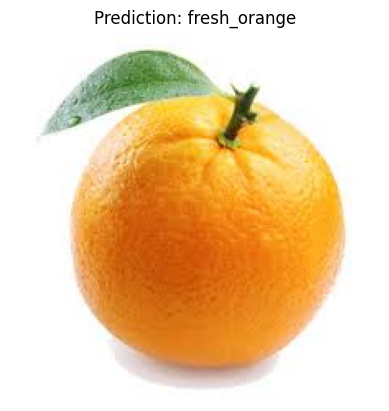

🍏 Predicted: fresh_orange


In [ ]:
# 🔹 Upload an image manually
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    image_path = filename  # Uploaded file will be in /content/
    print(f"✅ Uploaded file: {filename}")

if os.path.exists(image_path):
    prediction = predict_image(image_path)
    print(f"🍏 Predicted: {prediction}")
else:
    print("❌ Image file not found!")


In [ ]:
import pickle

# Save with custom prefix
torch.save(model.state_dict(), "/content/ViT+CNN_weights.pt")

with open("/content/ViT+CNN_full.pkl", "wb") as f:
    pickle.dump(model, f)

print("✅ Model saved as ViT+CNN_weights.pt and ViT+CNN_full.pkl")


✅ Model saved as ViT+CNN_weights.pt and ViT+CNN_full.pkl


In [ ]:
import torch
from google.colab import files

# Save full model
torch.save(model, "ViT+CNN_full.pt")

# Download to local
files.download("ViT+CNN_full.pt")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>